In [3]:
import json
import os

import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# loading data
data_path = "data/results/top50000_2025.json"

data = json.load(open(data_path, 'r'))

In [10]:
def local_frequency(data: dict, field: str) -> int:
    counter = 0

    for key in data.keys():
        if (type(data[key][field]) is list and len(data[key][field]) > 0) or data[key][field] == "true":
            counter += 1

    return counter

def draw_pie(data: dict, label: str, freq: int) -> None:
    labels = [label, f"no_{label}"]
    values = [freq, len(data) - freq]

    plt.pie(values, autopct='%1.2f%%', labels=labels, colors=["red", "green"])
    plt.axis('equal')
    plt.show()

## Import analysis

In this section we want to analysis how many times there are local imports inside a local scope. What we want to find is:
* how many times there are local imports inside a local scope

There are 5235 packages with local imports over the total of 49989 packages(10.47%).


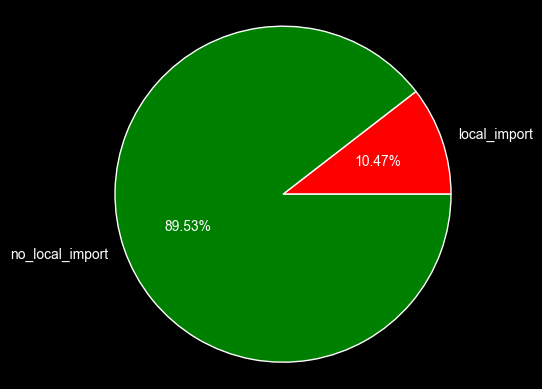

In [11]:
pkgs_w_local_imports = local_frequency(data, "local_import") # count the number of packages with local imports

print(f"There are {pkgs_w_local_imports} packages with local imports over the total of {len(data.keys())} packages({pkgs_w_local_imports/len(data.keys())*100:.2f}%).")

draw_pie(data, "local_import", pkgs_w_local_imports)

## Inner function analysis

We propose the same analysis that we done for the imports, but this time we want to find the number of times there are local functions defined inside a local scope.

There are 6321 packages with local imports over the total of 49989 packages(12.64%).


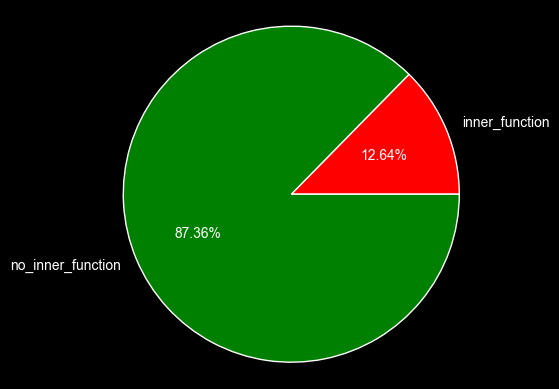

In [12]:
pkgs_w_local_functions = local_frequency(data, "inner_function") # count the number of packages with local functions

print(f"There are {pkgs_w_local_functions} packages with local imports over the total of {len(data.keys())} packages({pkgs_w_local_functions/len(data.keys())*100:.2f}%).")

draw_pie(data, "inner_function", pkgs_w_local_functions)

## Shadowing analysis

We want to see if the shadowing occurs into packages

There are 31780 packages with local imports over the total of 49989 packages(63.57%).


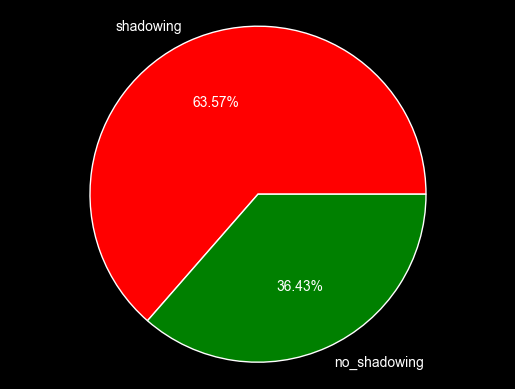

In [15]:
pkgs_w_shadowing = local_frequency(data, "shadowing")

print(f"There are {pkgs_w_shadowing} packages with local imports over the total of {len(data.keys())} packages({pkgs_w_shadowing/len(data.keys())*100:.2f}%).")

draw_pie(data, "shadowing", pkgs_w_shadowing)

## Monkey patching analysis

We want to see if in the wild the monkey patching is used. There are several way to do:
* presence and/or usage of **patch decorator**
* presence and/or usage of **context manager**
* usage of **atypical function** for with
* executing a **variables** swap inside a class

In [ ]:
pkgs_w_patch_decorator_import = local_frequency(data, "patch_decorator_import")

print(f"There are {pkgs_w_patch_decorator_import} packages with local imports over the total of {len(data.keys())} packages({pkgs_w_patch_decorator_import/len(data.keys())*100:.2f}%).")

draw_pie(data, "patch_decorator_import", pkgs_w_patch_decorator_import)

There are 103 packages with local imports over the total of 49989 packages(0.21%).


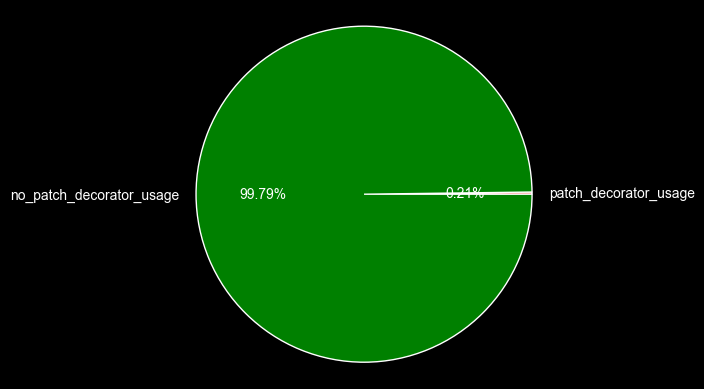

In [8]:
pkgs_w_patch_decorator_usage = local_frequency(data, "patch_decorator_usage")

print(f"There are {pkgs_w_patch_decorator_usage} packages with local imports over the total of {len(data.keys())} packages({pkgs_w_patch_decorator_usage/len(data.keys())*100:.2f}%).")

draw_pie(data, "patch_decorator_usage", pkgs_w_patch_decorator_usage)

There are 791 packages with local imports over the total of 49989 packages(1.58%).


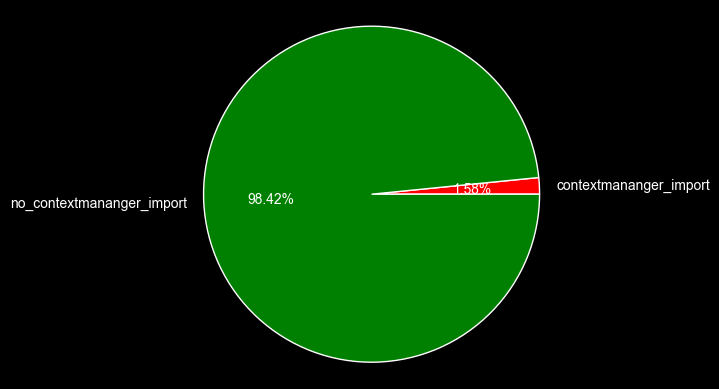

In [9]:
pkgs_w_contextmanager_import = local_frequency(data, "contextmanager_import")

print(f"There are {pkgs_w_contextmanager_import} packages with local imports over the total of {len(data.keys())} packages({pkgs_w_contextmanager_import/len(data.keys())*100:.2f}%).")

draw_pie(data, "contextmananger_import", pkgs_w_contextmanager_import)

There are 617 packages with local imports over the total of 49989 packages(1.23%).


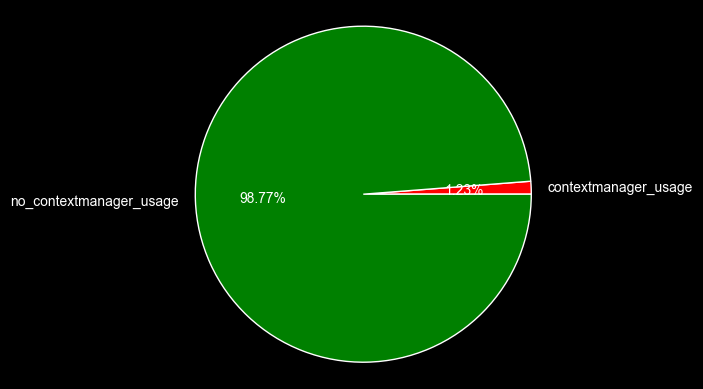

In [10]:
pkgs_w_contextmanager_usage = local_frequency(data, "contextmanager_usage")

print(f"There are {pkgs_w_contextmanager_usage} packages with local imports over the total of {len(data.keys())} packages({pkgs_w_contextmanager_usage/len(data.keys())*100:.2f}%).")

draw_pie(data, "contextmanager_usage", pkgs_w_contextmanager_usage)

There are 19373 packages with local imports over the total of 49989 packages(38.75%).


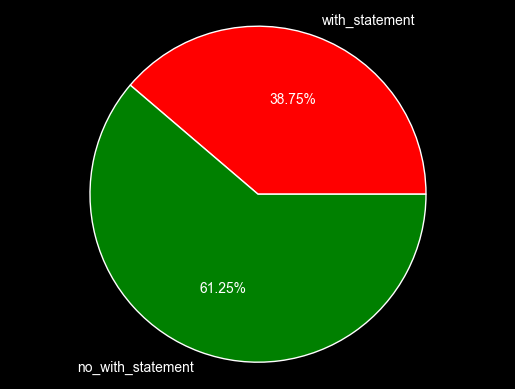

In [11]:
pkgs_w_with_statement = local_frequency(data, "with_statement")

print(f"There are {pkgs_w_with_statement} packages with local imports over the total of {len(data.keys())} packages({pkgs_w_with_statement/len(data.keys())*100:.2f}%).")

draw_pie(data, "with_statement", pkgs_w_with_statement)

There are 10528 packages with local imports over the total of 49989 packages(21.06%).


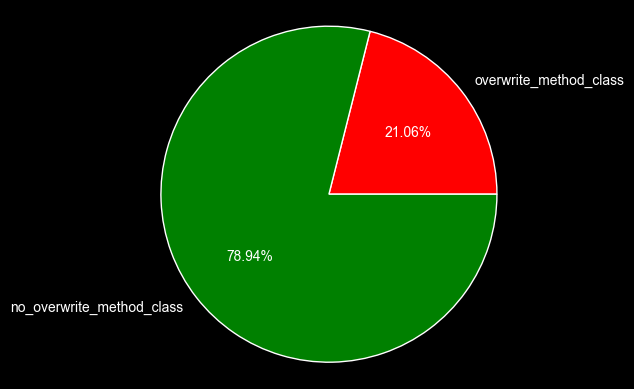

In [12]:
pkgs_w_overwrite_method_class = local_frequency(data, "overwrite_method_class")

print(f"There are {pkgs_w_overwrite_method_class} packages with local imports over the total of {len(data.keys())} packages({pkgs_w_overwrite_method_class/len(data.keys())*100:.2f}%).")

draw_pie(data, "overwrite_method_class", pkgs_w_overwrite_method_class)

Now let's deep dives into results looking which is the main cause of shadowing

In [13]:
# keeps packages where results has been detected
filtered = {k: v for k, v in data.items() if v.get("results") == "true"}

In [ ]:
# wangle data in a way to be able to have the frequencies of each combination
cols = list(filtered["boto3"].keys())[4: ]

df = pd.DataFrame([list(filtered[k].values())[4: ] for k in filtered.keys()], columns=cols, index=list(filtered.keys()))

# compute combination frequencies
#count_gb = df.groupby(cols)['overwrite_method_class'].count()
count_gb = df.groupby(cols)['results'].count()
df_combinations = df.groupby(cols).count()

df_combinations['freq'] = list(count_gb)
df_combinations.reset_index(inplace=True)

del df, count_gb

df_combinations.sort_values(by='freq', ascending=False)



## Scope chain mean length

Now we want to investigate which is the average length of the scope chain over the most popular packages

In [ ]:
mean = 0

for key in data.keys():
    mean += data[key]["scope_chain_length"]

mean /= len(data.keys())

print(f"Mean chain length: {mean}")

# Temporal data

In 2025 we see an higher number of package with shadowing, so we see how this phenomenon evolved over time from 2016 to today.
We decide to perform the following analysis:
*

In [1]:
def count_shadowing(data: dict):
    count = 0 # counter contains the number of packages where has been detected

    for key in data.keys():
        try:
            if data[key]["shadowing"] == "true":
                count += 1
        except TypeError:
            pass

    return count / len(data.keys()) * 100

In [4]:
# gather data about shadowing
results_dir = "./data/results"
shadowing = {}

for file in sorted(os.listdir(results_dir)):
    data = json.load(open(f"{results_dir}/{file}"))
    year = file.split("_")[-1].replace(".json", "")

    shadowing[f"{year}"] = count_shadowing(data)

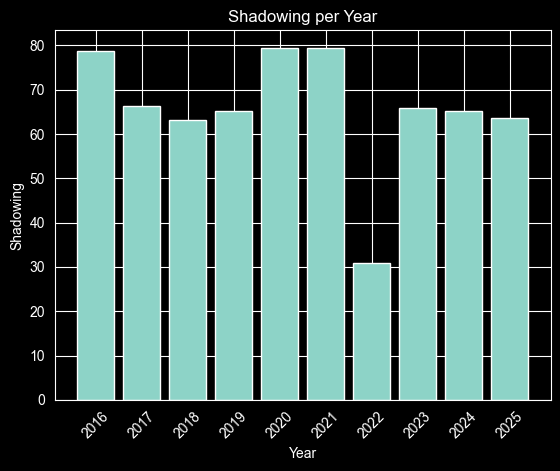

In [6]:
plt.figure()
plt.bar(shadowing.keys(), shadowing.values())

plt.xlabel("Year")
plt.ylabel("Shadowing")
plt.title("Shadowing per Year")
plt.xticks(rotation=45)

plt.show()

# Conclusions

# TODO:da scrivere conclusioni